<a href="https://colab.research.google.com/github/VENNELA2132/NN-practise/blob/main/makemore_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [147]:
words = open('/content/names.txt').read().splitlines()

In [148]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [149]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
itos = {i+1:s for i,s in enumerate(chars)}
stoi['.'] = 0
itos[0] = '.'


In [150]:
block_size = 3 # no. of chars we check for predicting the next one
X, Y = [], []
for w in words:
  # print(w)
  context = [0] * block_size
  for ch in (w + '.'):
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), "---->", ch)
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [151]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [152]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [153]:
# X

In [154]:
C = torch.randn((27,2))
# C

In [155]:
emb = C[X]
# emb

In [156]:
# emb[0]

In [157]:
#---training----

In [158]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [174]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g, requires_grad=True)
# emb = C[Xtr]  # [32,3,2]
# emb.view(-1,6)
W1 = torch.randn((30,200), generator=g, requires_grad=True) # 100 neutrons, 6 inputs --> eg: . . . == vector of 30 (10D for each char)
b1 = torch.randn((200), generator=g, requires_grad=True)

W2 = torch.randn((200, 27), generator=g, requires_grad=True)
b2 = torch.randn((27), generator=g, requires_grad=True)

params = [C, W1, W2, b1, b2]


In [175]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [176]:
lri = []
lossi = []
stepi = []

In [177]:
for i in range(200000):

  #minibatch
  ix = torch.randint(0, Xtr.shape[0], (32,))


  # forward pass
  emb = C[Xtr[ix]]  # [32,3,2]
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # [32,100]
  logits = h @ W2 + b2  # [32, 27]
  # counts = logits.exp()
  # prob = counts / counts.sum(1, keepdim=True)
  # loss = -prob[torch.arange(32), Y].log().mean()
  loss = F.cross_entropy(logits, Ytr[ix])

  # print(loss.item())

  # backward pass
  for p in params:
    p.grad = None
  # print(loss.item())
  loss.backward()

  # lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in params:
    p.data += -(lr) * p.grad

  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

# print(loss.item())

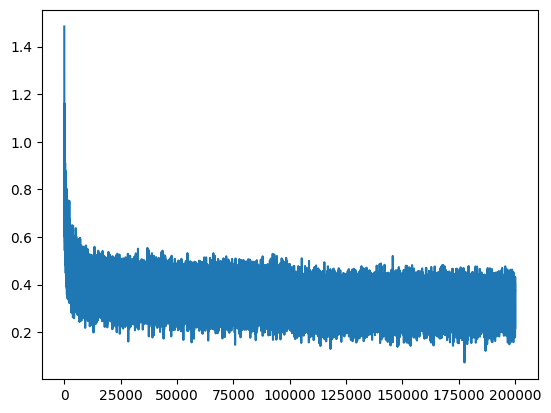

In [178]:
plt.plot(stepi, lossi)

In [179]:
emb = C[Xtr]  # [32,3,2]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # [32,100]
logits = h @ W2 + b2  # [32, 27]
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.122277021408081

In [180]:
emb = C[Xdev]  # [32,3,2]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # [32,100]
logits = h @ W2 + b2  # [32, 27]
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.162245273590088

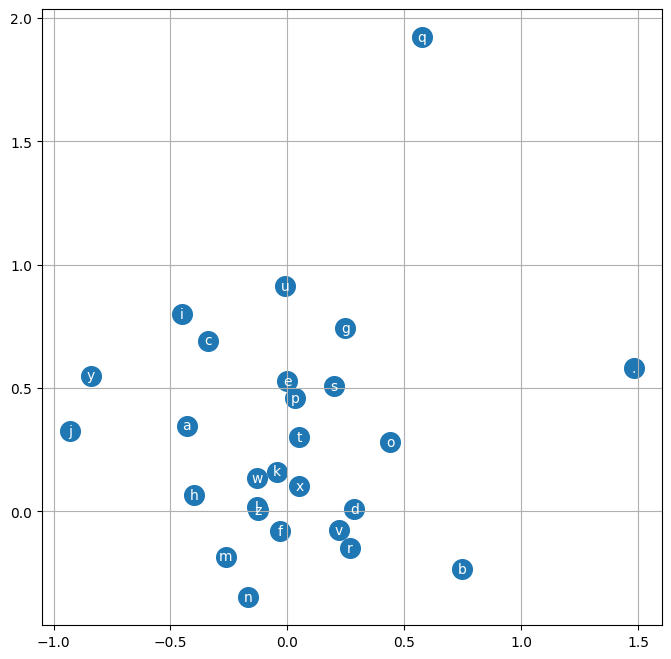

In [181]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [182]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [184]:
# sample from the model
g = torch.Generator().manual_seed(2147483665)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

mademal.
niah.
aje.
aarina.
emiah.
jah.
mikomiaz.
tta.
mayiella.
macenttannoe.
saya.
irzanton.
maelen.
maxy.
xylurewendina.
ramai.
adan.
alon.
rave.
zalen.


In [80]:
logits.max(1)

torch.return_types.max(
values=tensor([4.1250, 3.1830, 2.2304, 2.0956, 2.5395, 4.1187, 2.2277, 2.9203, 2.2407,
        1.9634, 3.2968, 2.4388, 2.0509, 2.6487, 2.4109, 2.1005, 4.9683, 2.8755,
        5.0674, 3.1709, 3.6478, 2.0921, 3.7990, 3.3890, 2.6445, 4.1187, 3.1629,
        3.0395, 2.1371, 2.6355, 4.1250, 1.9246], grad_fn=<MaxBackward0>),
indices=tensor([ 1,  5, 15, 14, 14,  1,  0,  1,  1,  0, 14,  0,  0, 14,  0,  1,  1,  0,
         1,  1,  1,  0,  1,  0,  0,  1,  1,  1,  0,  0,  1,  5]))

In [33]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])